In [1]:
!pip install pyarrow

### FASE 1 SOLO LECTURA 

In [ ]:


import pandas as pd
import numpy as np


PARQUET_PATH = "data/processed/defunciones_v2.parquet"  
MUESTRA_FILAS = 10                               


def _mem_mb(df):
    return df.memory_usage(deep=True).sum() / (1024**2)

def leer_parquet_basico(path):
    
    
    df = pd.read_parquet(path, engine="pyarrow")
    return df

if __name__ == "__main__":
    df = leer_parquet_basico(PARQUET_PATH)

    
    n_filas, n_cols = df.shape
    print("=== LECTURA COMPLETA ===")
    print(f"Ruta: {PARQUET_PATH}")
    print(f"Filas: {n_filas:,} | Columnas: {n_cols:,}")
    print(f"Memoria estimada: {_mem_mb(df):.2f} MB\n")

    
    print("=== COLUMNAS Y TIPOS ===")
    print(df.dtypes.astype(str).to_string())
    print("\n=== PRIMERAS FILAS ===")
    print(df.head(MUESTRA_FILAS).to_string(index=False))


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\User\\Downloads\\defunciones_v2.parquet'

#### LIMPUEZA MÍNIMA Y DICCIONARIO 

In [ ]:

import os
import json
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


PARQUET_IN   = r"C:\Users\User\Downloads\defunciones_v2.parquet"
PARQUET_OUT  = "outputs_fase2/df_limpio.parquet"
OUTPUT_DIR   = "outputs_fase2"
VISTA_GEO    = "RESIDENCIA"


os.makedirs(OUTPUT_DIR, exist_ok=True)

def _std_text_series(s: pd.Series) -> pd.Series:
    
    s = s.astype("string")
    s = s.str.strip()
    s = s.str.replace(r"\s+", " ", regex=True)
    return s

def _to_title_geo(s: pd.Series) -> pd.Series:
    
    s = _std_text_series(s)
    return s.str.title()

def _build_fecha(df: pd.DataFrame) -> pd.Series:
    
    anio = pd.to_numeric(df["ANO"], errors="coerce").astype("Int64")
    mes  = pd.to_numeric(df["MES"], errors="coerce").astype("Int64")
    
    mes = mes.fillna(1).astype("Int64")
    fecha = pd.to_datetime(
        dict(year=anio.fillna(2000).astype("int64"),
             month=mes.fillna(1).astype("int64"),
             day=1),
        errors="coerce"
    )
    return fecha

def _clean_desc_columns(df: pd.DataFrame) -> pd.DataFrame:
    
    df2 = df.copy()
    desc_cols = [c for c in df2.columns if c.endswith("_DESC")]
    for c in desc_cols:
        df2[c] = _std_text_series(df2[c])
        df2[c] = df2[c].fillna("No registra")

    
    if VISTA_GEO.upper() == "RESIDENCIA":
        geo_dep = "NOMBRE_DEPARTAMENTO_RESIDENCIA"
        geo_mun = "NOMBRE_MUNICIPIO_RESIDENCIA"
    else:
        geo_dep = "NOMBRE_DEPARTAMENTO_OCURRENCIA"
        geo_mun = "NOMBRE_MUNICIPIO_OCURRENCIA"

    for c in [geo_dep, geo_mun]:
        if c in df2.columns:
            df2[c] = _to_title_geo(df2[c]).fillna("No registra")

    
    for c in ["NOMBRE_DEPARTAMENTO", "NOMBRE_MUNICIPIO"]:
        if c in df2.columns:
            df2[c] = _to_title_geo(df2[c]).fillna("No registra")

    return df2

def _drop_dups(df: pd.DataFrame) -> pd.DataFrame:
    before = len(df)
    df2 = df.drop_duplicates()
    after = len(df2)
    print(f"Duplicados eliminados: {before - after}")
    return df2

def _dict_datos(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    n = len(df)
    for c in df.columns:
        s = df[c]
        rows.append({
            "columna": c,
            "tipo_dato": str(s.dtype),
            "porc_nulos": round(s.isna().mean()*100, 2),
            "n_unicos": int(s.nunique(dropna=True)),
            "ejemplo": (s.dropna().iloc[0] if s.dropna().shape[0] else None)
        })
    dicc = pd.DataFrame(rows).sort_values(["tipo_dato","columna"]).reset_index(drop=True)
    return dicc

def _plot_completitud(df: pd.DataFrame, outpath: str):
    null_frac = df.isna().mean().to_dict()
    labels = list(null_frac.keys())
    completeness = [1 - null_frac[k] for k in labels]
    order = np.argsort(completeness)
    labels_ord = [labels[i] for i in order]
    compl_ord = [completeness[i] for i in order]
    plt.figure(figsize=(10, max(4, len(labels)*0.25)))
    plt.barh(labels_ord, compl_ord)
    plt.xlabel("Proporción de completitud (1 - nulos)")
    plt.title("Completitud por columna (post-limpieza mínima)")
    plt.tight_layout()
    plt.savefig(outpath)
    plt.close()

def _plot_top_barras(df: pd.DataFrame, col: str, titulo: str, outpath: str, topn: int = 15):
    if col not in df.columns:
        return
    vc = df[col].astype("string").fillna("No registra").value_counts().head(topn)
    plt.figure(figsize=(10, max(3.5, 0.35*len(vc))))
    plt.barh(vc.index.tolist()[::-1], vc.values.tolist()[::-1])
    plt.title(titulo)
    plt.xlabel("Frecuencia")
    plt.tight_layout()
    plt.savefig(outpath)
    plt.close()

def _plot_serie_mensual(df: pd.DataFrame, outpath: str):
    if "FECHA" not in df.columns:
        return
    serie = df.set_index("FECHA").sort_index()
    
    ts = serie.resample("MS").size()
    if len(ts) == 0:
        return
    plt.figure(figsize=(10,4))
    plt.plot(ts.index, ts.values)
    plt.title("Serie mensual de registros")
    plt.xlabel("Mes")
    plt.ylabel("Conteos")
    plt.tight_layout()
    plt.savefig(outpath)
    plt.close()

def main():
    print(f"[{datetime.now()}] Cargando: {PARQUET_IN}")
    df = pd.read_parquet(PARQUET_IN, engine="pyarrow")

    
    if "ANO" in df.columns and "MES" in df.columns:
        df["FECHA"] = _build_fecha(df)

    
    df = _clean_desc_columns(df)

    
    df = _drop_dups(df)

    
    out_parquet = os.path.join(OUTPUT_DIR, os.path.basename(PARQUET_OUT))
    df.to_parquet(out_parquet, index=False)
    print(f"Guardado parquet limpio: {os.path.abspath(out_parquet)}")

    
    dicc = _dict_datos(df)
    dicc_path = os.path.join(OUTPUT_DIR, "diccionario_datos_fase2.csv")
    dicc.to_csv(dicc_path, index=False, encoding="utf-8-sig")
    print(f"Diccionario de datos: {os.path.abspath(dicc_path)}")

    
    _plot_completitud(df, os.path.join(OUTPUT_DIR, "completitud_post_limpieza.png"))

    
    if "CAU_HOMOL_DESC" in df.columns:
        _plot_top_barras(df, "CAU_HOMOL_DESC", "Top causas homologadas (CAU_HOMOL_DESC)",
                         os.path.join(OUTPUT_DIR, "top_causas_homologadas.png"))
    if "PMAN_MUER_DESC" in df.columns:
        _plot_top_barras(df, "PMAN_MUER_DESC", "Top presunta manera de muerte (PMAN_MUER_DESC)",
                         os.path.join(OUTPUT_DIR, "top_manera_muerte.png"))

    
    _plot_serie_mensual(df, os.path.join(OUTPUT_DIR, "serie_mensual_registros.png"))

    
    meta = {
        "parquet_limpio": out_parquet,
        "diccionario_csv": dicc_path,
        "graficos": [
            "completitud_post_limpieza.png",
            "top_causas_homologadas.png (si aplica)",
            "top_manera_muerte.png (si aplica)",
            "serie_mensual_registros.png (si aplica)"
        ]
    }
    with open(os.path.join(OUTPUT_DIR, "fase2_meta.json"), "w", encoding="utf-8") as f:
        json.dump(meta, f, ensure_ascii=False, indent=2)

    print("\n=== Fase 2 completada (mínima) ===")
    print(f"- Parquet limpio: {out_parquet}")
    print(f"- Diccionario: {dicc_path}")
    print(f"- Gráficos en: {os.path.abspath(OUTPUT_DIR)}")

if __name__ == "__main__":
    main()


[2025-11-10 21:14:33.244017] Cargando: C:\Users\User\Downloads\defunciones_v2.parquet
Duplicados eliminados: 60680
Guardado parquet limpio: c:\Users\User\AppData\Local\Programs\Microsoft VS Code\outputs_fase2\df_limpio.parquet
Diccionario de datos: c:\Users\User\AppData\Local\Programs\Microsoft VS Code\outputs_fase2\diccionario_datos_fase2.csv

=== Fase 2 completada (mínima) ===
- Parquet limpio: outputs_fase2\df_limpio.parquet
- Diccionario: outputs_fase2\diccionario_datos_fase2.csv
- Gráficos en: c:\Users\User\AppData\Local\Programs\Microsoft VS Code\outputs_fase2


### FASE 3 DESCRIPTIVOS UNIVARIADOS

Registros totales: 3,595,388 | En análisis (solo NATURALES): 1,702,535

=== Resumen de variables (muestra) ===
                       columna      tipo_dato  nulos_%  n_unicos
                           ANO          Int64     0.00        15
                      ASIS_MED          Int64     0.00         4
                     CAUSA_666          Int64     4.68        64
                     CAUSA_667          Int64    19.91        63
                     CAU_HOMOL          Int64     0.00        99
                      CONS_EXP          Int64     0.00         6
                      C_MUERTE          Int64    92.61         1
                     C_MUERTEB          Int64    24.63         1
                     C_MUERTEC          Int64    91.27         1
                     C_MUERTED          Int64    71.83         1
                     EST_CIVIL          Int64     0.00         7
                           MES          Int64     0.00        12
                     NIVEL_EDU          Int6

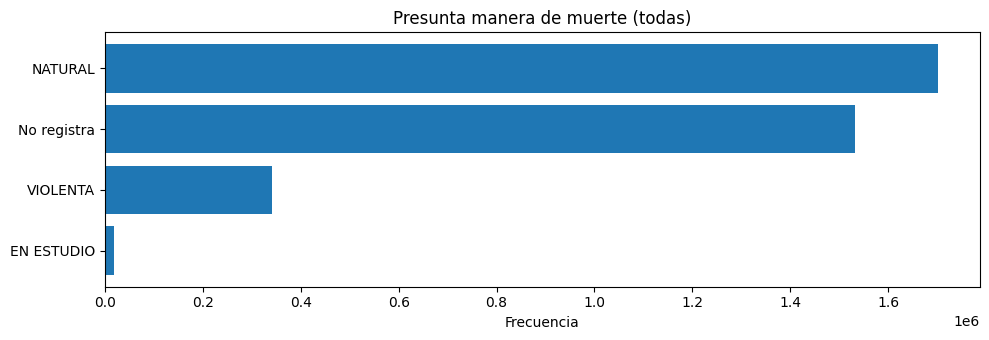

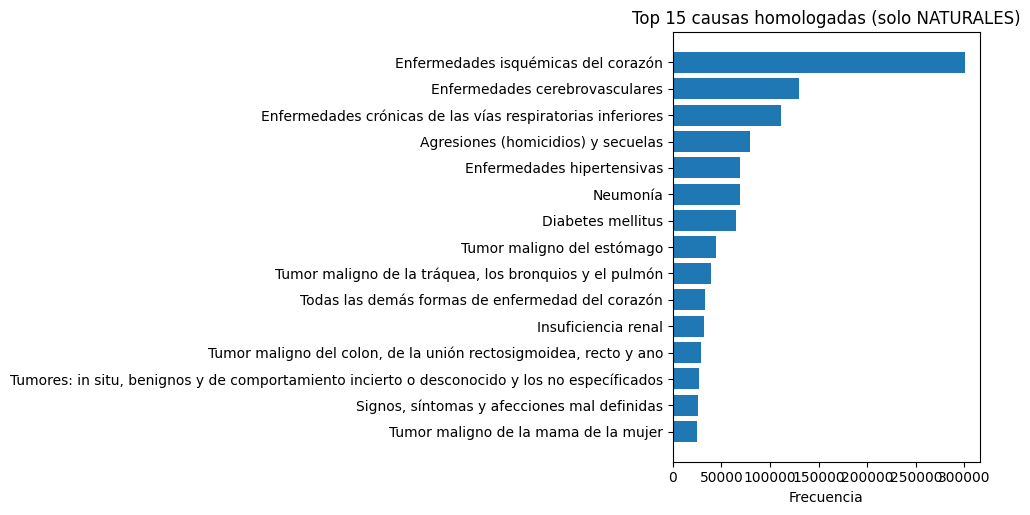

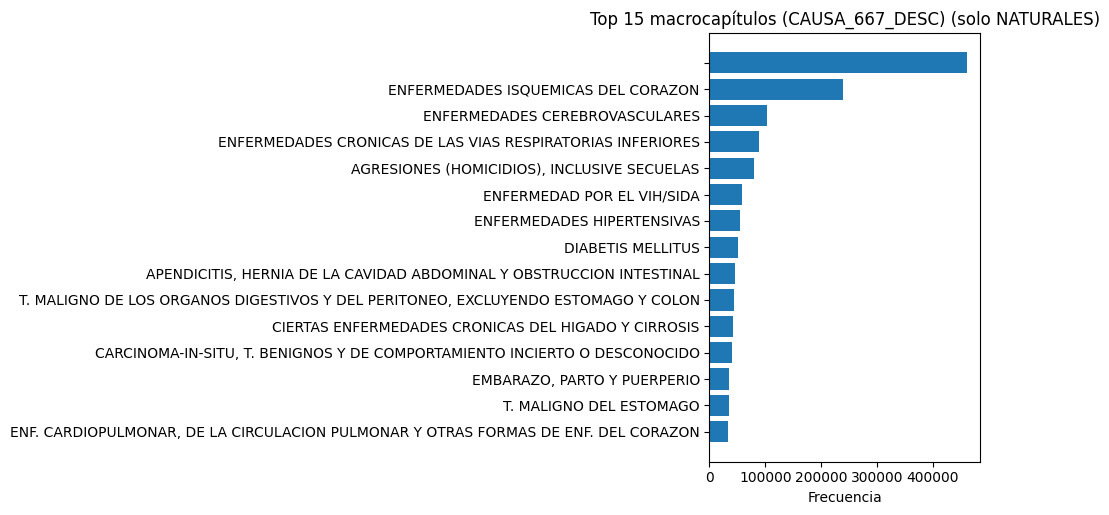

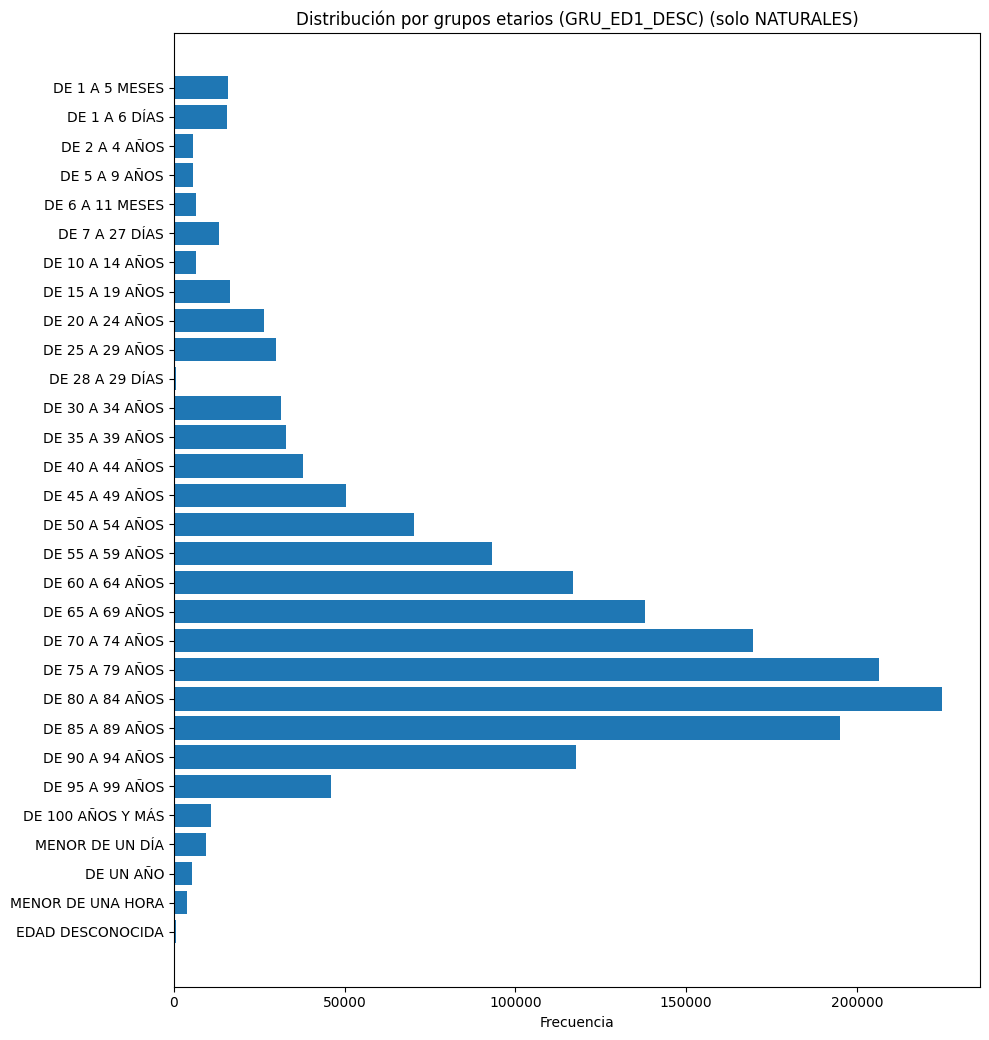

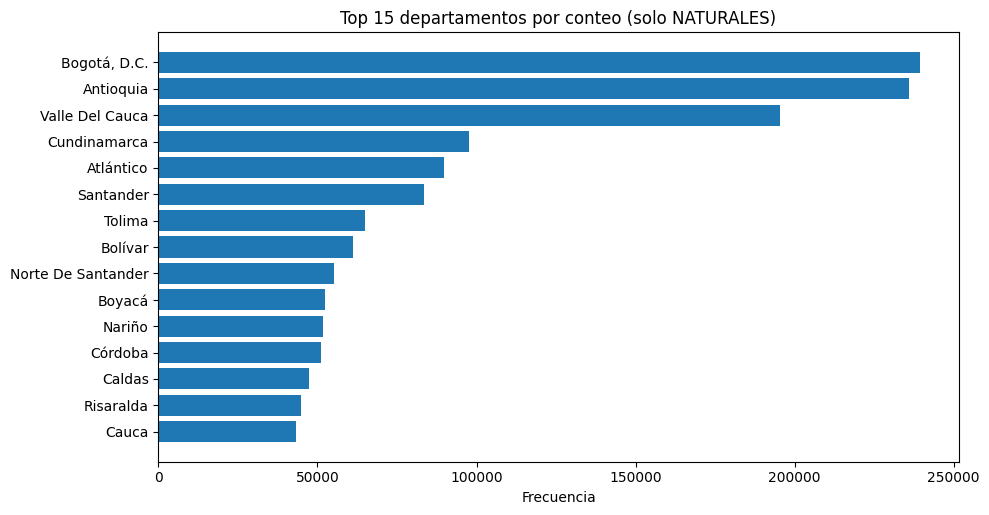

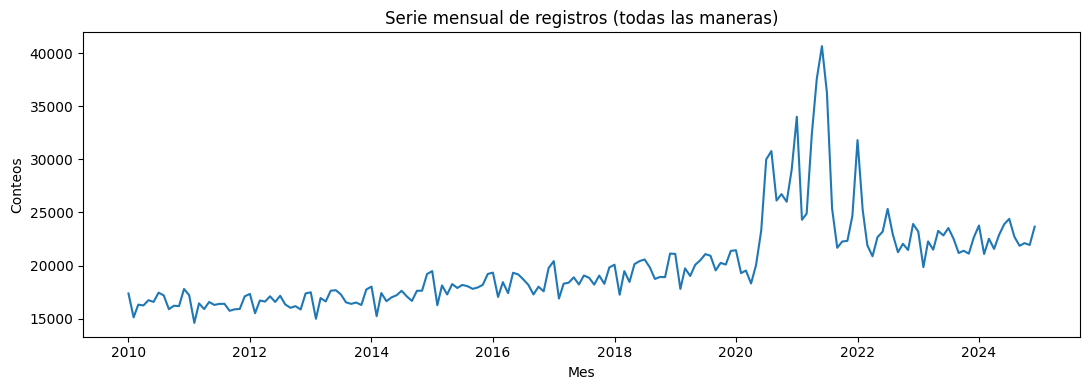

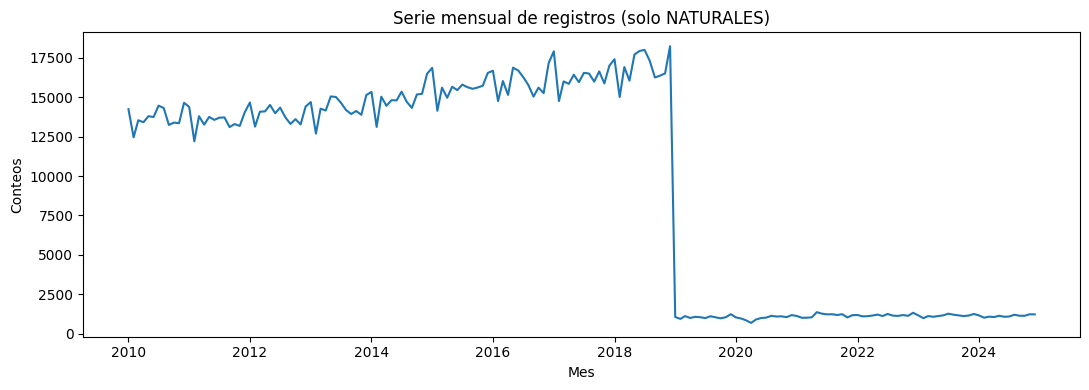


=== Cobertura por año y departamento (conteos) — vista parcial ===
NOMBRE_DEPARTAMENTO_RESIDENCIA  Amazonas  Antioquia  Arauca  Archipiélago De San Andrés, Providencia Y Santa Catalina  Atlántico  Bogotá, D.C.  Bolívar  Boyacá  Caldas  Caquetá
ANO                                                                                                                                                                             
2010                                 146      23400     663                                                       187       7585         24452     5401    5622    4978     1292
2011                                 142      22855     617                                                       188       7014         24622     5213    5611    4848     1300
2012                                 168      23174     677                                                       185       8389         25638     5856    5672    4986     1208
2013                                 182      2

In [ ]:

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


PARQUET_IN = r"C:\Users\User\AppData\Local\Programs\Microsoft VS Code\outputs_fase2\df_limpio.parquet"
TOPN = 15                                         # Top-N categorías a graficar
SCOPE_NATURALES = True                            # True: filtra a presunta manera NATURAL


pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

def build_fecha(df: pd.DataFrame) -> pd.DataFrame:
    """Si no existe FECHA, créala a partir de ANO y MES."""
    if "FECHA" not in df.columns and {"ANO","MES"}.issubset(df.columns):
        anio = pd.to_numeric(df["ANO"], errors="coerce").astype("Int64")
        mes  = pd.to_numeric(df["MES"], errors="coerce").astype("Int64").fillna(1)
        df["FECHA"] = pd.to_datetime(
            dict(year=anio.fillna(2000).astype("int64"),
                 month=mes.astype("int64"),
                 day=1), errors="coerce"
        )
    return df

def normalizar_modo_muerte(df: pd.DataFrame) -> pd.DataFrame:
    """Estandariza PMAN_MUER_DESC: cadenas vacías -> 'No registra'."""
    if "PMAN_MUER_DESC" in df.columns:
        s = df["PMAN_MUER_DESC"].astype("string")
        s = s.fillna("No registra").str.strip()
        s = s.replace("", "No registra")
        df["PMAN_MUER_DESC"] = s
    return df

def filtrar_naturales(df: pd.DataFrame) -> pd.DataFrame:
    """Filtra registros NATURALES si SCOPE_NATURALES es True."""
    if SCOPE_NATURALES and "PMAN_MUER_DESC" in df.columns:
        return df[df["PMAN_MUER_DESC"].str.upper() == "NATURAL"].copy()
    return df

def resumen_variables(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for c in df.columns:
        s = df[c]
        rows.append({
            "columna": c,
            "tipo_dato": str(s.dtype),
            "nulos_%": round(s.isna().mean()*100, 2),
            "n_unicos": int(s.nunique(dropna=True))
        })
    dicc = pd.DataFrame(rows).sort_values(["tipo_dato","columna"]).reset_index(drop=True)
    return dicc

def plot_barh(vc: pd.Series, titulo: str, xlabel: str = "Frecuencia"):
    if vc.empty:
        print(f"[AVISO] Serie vacía para gráfico: {titulo}")
        return
    plt.figure(figsize=(10, max(3.5, 0.35*len(vc))))
    plt.barh(vc.index.tolist()[::-1], vc.values.tolist()[::-1])
    plt.title(titulo)
    plt.xlabel(xlabel)
    plt.tight_layout()
    plt.show()

def plot_serie_mensual(df: pd.DataFrame, titulo: str):
    if "FECHA" not in df.columns:
        print("[AVISO] No existe FECHA; no se grafica serie mensual.")
        return
    ts = (df
          .set_index("FECHA")
          .sort_index()
          .resample("MS")
          .size())
    if len(ts) == 0:
        print("[AVISO] Serie mensual vacía.")
        return
    plt.figure(figsize=(11,4))
    plt.plot(ts.index, ts.values)
    plt.title(titulo)
    plt.xlabel("Mes")
    plt.ylabel("Conteos")
    plt.tight_layout()
    plt.show()

def main():
    
    df = pd.read_parquet(PARQUET_IN)
    df = build_fecha(df)
    df = normalizar_modo_muerte(df)

   
    n0 = len(df)
    df_scope = filtrar_naturales(df)
    scope_txt = " (solo NATURALES)" if SCOPE_NATURALES else " (todas las maneras)"
    print(f"Registros totales: {n0:,} | En análisis{scope_txt}: {len(df_scope):,}")

    
    dicc = resumen_variables(df_scope)
    print("\n=== Resumen de variables (muestra) ===")
    print(dicc.head(20).to_string(index=False))
    print("\n=== Variables con alta cardinalidad (n_unicos > 1000) ===")
    print(dicc[dicc["n_unicos"] > 1000].sort_values("n_unicos", ascending=False).to_string(index=False))

    
    if "PMAN_MUER_DESC" in df.columns:
        vc_modo = df["PMAN_MUER_DESC"].value_counts()
        plot_barh(vc_modo, "Presunta manera de muerte (todas)", "Frecuencia")

    if "CAU_HOMOL_DESC" in df_scope.columns:
        vc_causa = df_scope["CAU_HOMOL_DESC"].astype("string").fillna("No registra").value_counts().head(TOPN)
        plot_barh(vc_causa, f"Top {TOPN} causas homologadas{scope_txt}", "Frecuencia")

    if "CAUSA_667_DESC" in df_scope.columns:
        vc_c667 = df_scope["CAUSA_667_DESC"].astype("string").fillna("No registra").value_counts().head(TOPN)
        plot_barh(vc_c667, f"Top {TOPN} macrocapítulos (CAUSA_667_DESC){scope_txt}", "Frecuencia")

    if "GRU_ED1_DESC" in df_scope.columns:
        vc_edad = df_scope["GRU_ED1_DESC"].astype("string").fillna("No registra").value_counts()
        
        try:
            def clave_edad(x):
                m = re.search(r"(\d+)\s*A\s*(\d+)", x.replace("DE","").replace("AÑOS",""))
                return int(m.group(1)) if m else 9999
            orden = sorted(vc_edad.index.tolist(), key=clave_edad)
            vc_edad = vc_edad.reindex(orden)
        except Exception:
            pass
        plot_barh(vc_edad, f"Distribución por grupos etarios (GRU_ED1_DESC){scope_txt}", "Frecuencia")

    
    dep_col = None
    for c in ["NOMBRE_DEPARTAMENTO_RESIDENCIA", "NOMBRE_DEPARTAMENTO_OCURRENCIA", "NOMBRE_DEPARTAMENTO"]:
        if c in df_scope.columns:
            dep_col = c
            break
    if dep_col:
        vc_dep = df_scope[dep_col].astype("string").fillna("No registra").value_counts().head(TOPN)
        plot_barh(vc_dep, f"Top {TOPN} departamentos por conteo{scope_txt}", "Frecuencia")

    
    plot_serie_mensual(df, "Serie mensual de registros (todas las maneras)")
    plot_serie_mensual(df_scope, f"Serie mensual de registros{scope_txt}")

    
    if "ANO" in df_scope.columns and dep_col:
        tabla = (df_scope
                 .groupby(["ANO", dep_col], dropna=False)
                 .size()
                 .reset_index(name="conteo")
                 .pivot(index="ANO", columns=dep_col, values="conteo")
                 .fillna(0)
                 .astype(int))
        print("\n=== Cobertura por año y departamento (conteos) — vista parcial ===")
        
        print(tabla.iloc[:10, :10].to_string())
        

    
    

if __name__ == "__main__":
    main()


#### Fase 4 — Relaciones y correlaciones

Registros en análisis (todas las maneras): 3,595,388

=== Panel Depto–Mes (muestra) ===
NOMBRE_DEPARTAMENTO_RESIDENCIA      FECHA  y_conteo  prop_sexo_femenino  prop_sexo_indeterminado  prop_sexo_masculino  prop_edad_de 45 a 49 años  prop_edad_de 50 a 54 años  prop_edad_de 55 a 59 años  prop_edad_de 60 a 64 años  prop_edad_de 65 a 69 años  prop_edad_de 70 a 74 años  prop_edad_de 75 a 79 años  prop_edad_de 80 a 84 años  prop_edad_de 85 a 89 años  prop_edad_de 90 a 94 años  prop_causa_accidentes de transporte de motor y secuelas  prop_causa_agresiones (homicidios) y secuelas  prop_causa_diabetes mellitus  prop_causa_enfermedades cerebrovasculares  prop_causa_enfermedades crónicas de las vías respiratorias inferiores  prop_causa_enfermedades hipertensivas  prop_causa_enfermedades isquémicas del corazón  prop_causa_neumonía  prop_causa_todas las demás enfermedades infecciosas y parasitarias  prop_causa_tumor maligno del estómago  prop_asistencia_si
                      Amazonas 2010-01-01

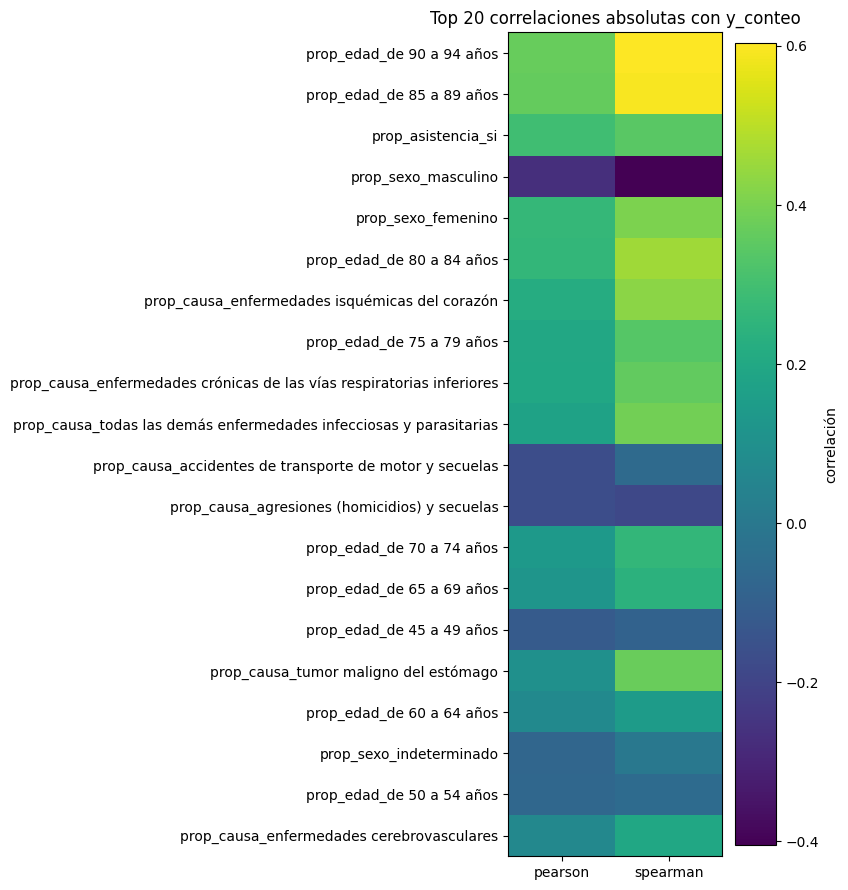

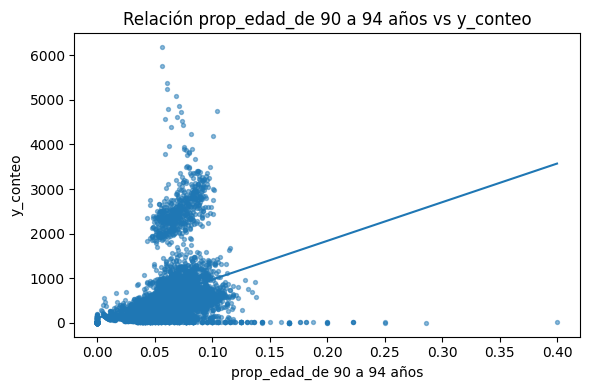

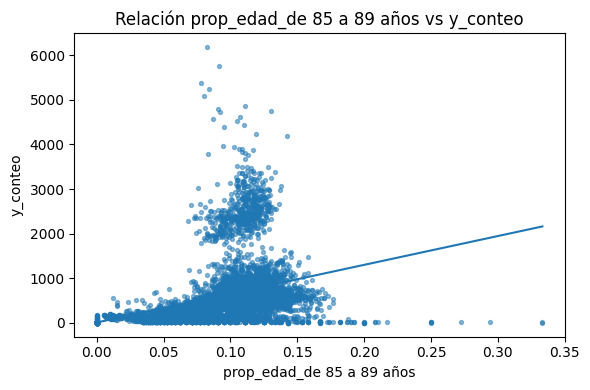

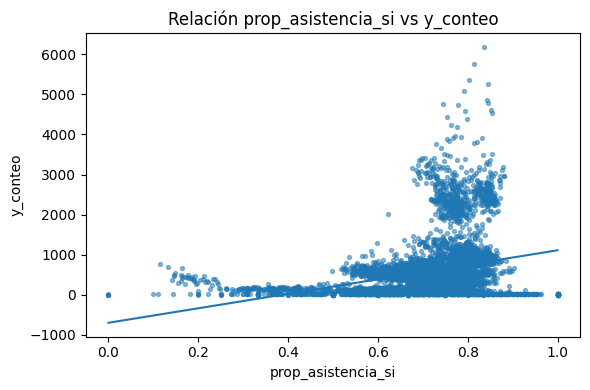

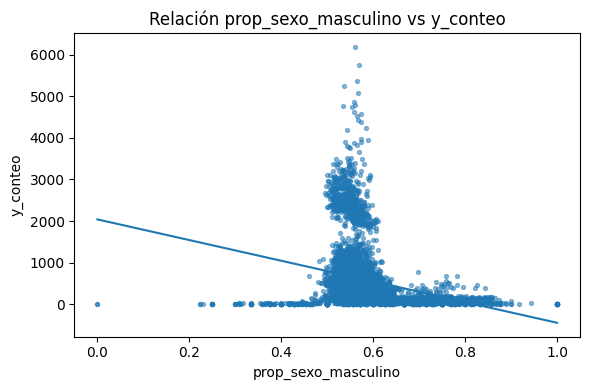

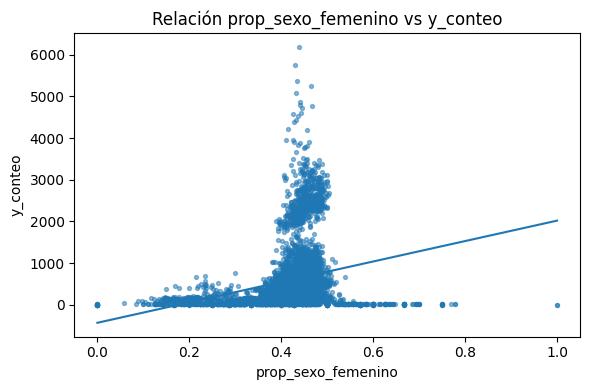

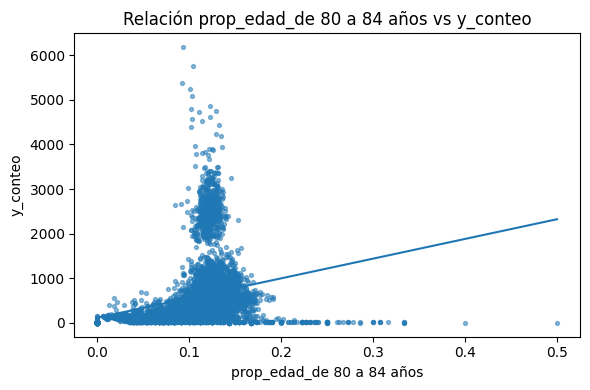

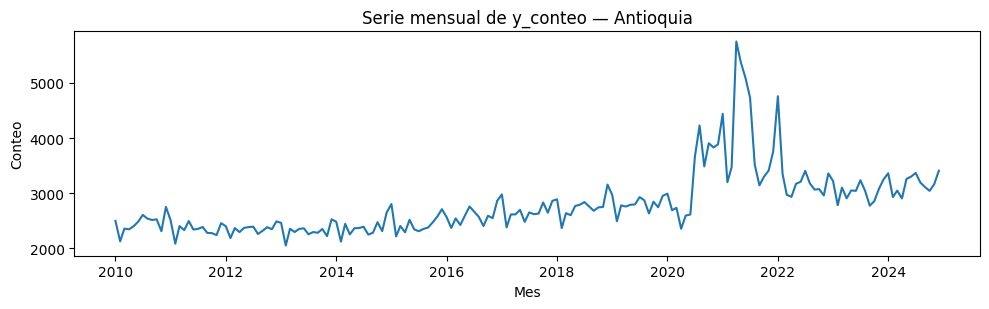

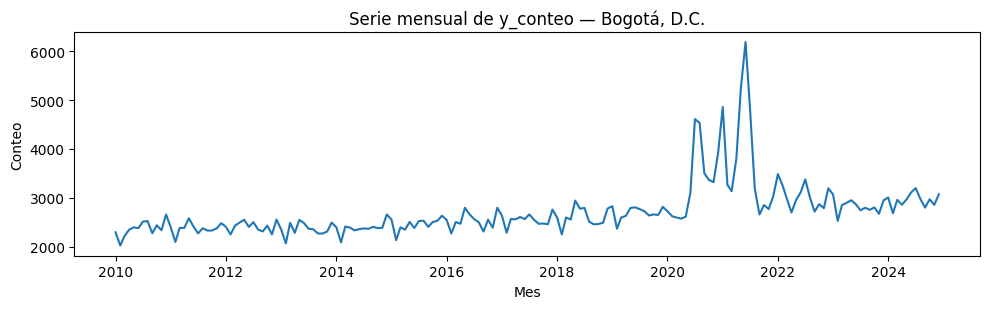

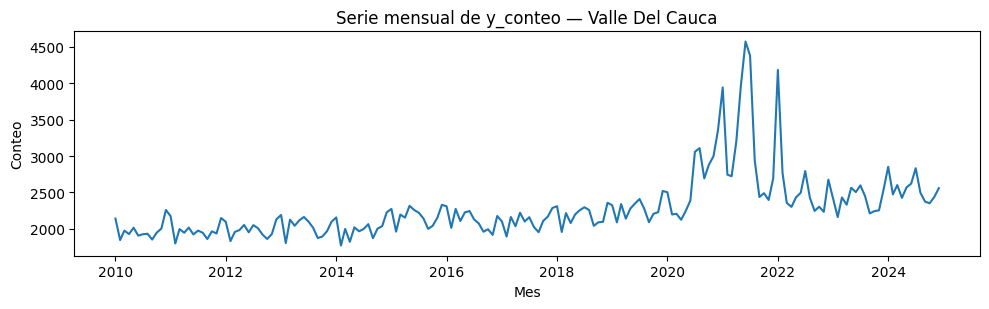

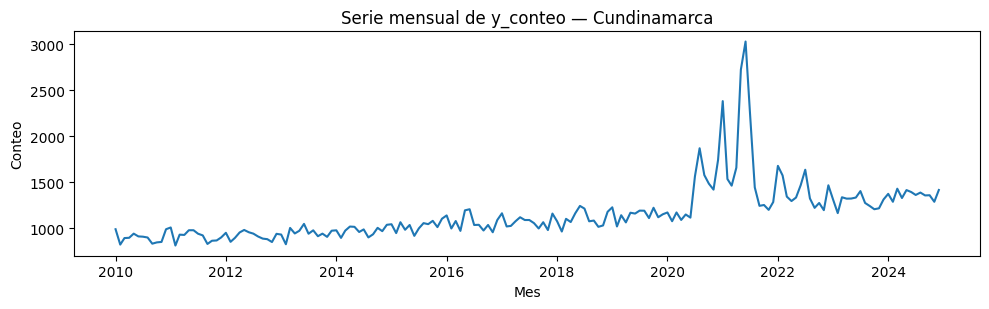

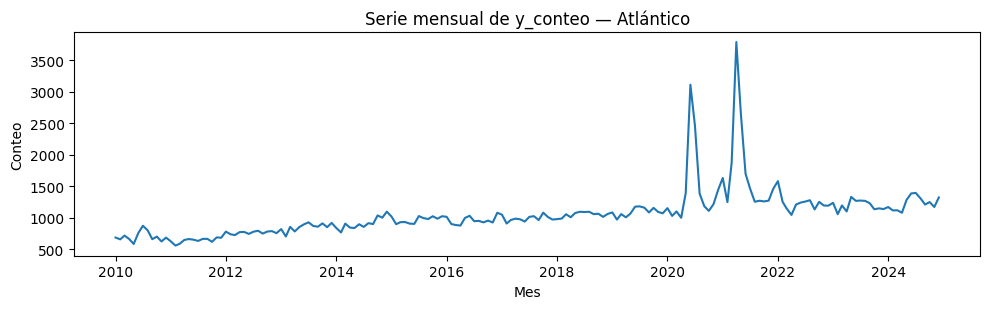

In [ ]:


import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


PARQUET_IN = r"C:\Users\User\AppData\Local\Programs\Microsoft VS Code\outputs_fase2\df_limpio.parquet"
DEP_COL = "NOMBRE_DEPARTAMENTO_RESIDENCIA"  # vista geográfica elegida
TOP_CAUSAS = 10                              # top causas homologadas a convertir en proporciones
TOP_EDADES = 10                              # top grupos etarios a convertir en proporciones
SCOPE_NATURALES = False                      # True -> solo NATURALES; False -> todas las maneras


pd.set_option("display.max_columns", 140)
pd.set_option("display.width", 180)


def _chk_cols(df, cols):
    faltan = [c for c in cols if c not in df.columns]
    if faltan:
        raise ValueError(f"Faltan columnas necesarias: {faltan}")

def _build_fecha(df):
    if "FECHA" not in df.columns and {"ANO","MES"}.issubset(df.columns):
        anio = pd.to_numeric(df["ANO"], errors="coerce").astype("Int64")
        mes  = pd.to_numeric(df["MES"], errors="coerce").astype("Int64").fillna(1)
        df["FECHA"] = pd.to_datetime(
            dict(year=anio.fillna(2000).astype("int64"),
                 month=mes.astype("int64"),
                 day=1), errors="coerce"
        )
    return df

def _normalizar(df):
   
    if "PMAN_MUER_DESC" in df.columns:
        s = df["PMAN_MUER_DESC"].astype("string").fillna("No registra").str.strip()
        df["PMAN_MUER_DESC"] = s.replace("", "No registra")
    
    for c in ["CAU_HOMOL_DESC","GRU_ED1_DESC","SEXO_DESC"]:
        if c in df.columns:
            df[c] = df[c].astype("string").fillna("No registra").str.strip()
    return df

def _filtrar_naturales(df):
    if SCOPE_NATURALES and "PMAN_MUER_DESC" in df.columns:
        return df[df["PMAN_MUER_DESC"].str.upper() == "NATURAL"].copy()
    return df

def _armar_panel(df):
    
    grp = df.groupby([DEP_COL, "FECHA"], dropna=False)
    y = grp.size().rename("y_conteo")

    # Proporciones por sexo (si existe SEXO_DESC)
    feats = []
    if "SEXO_DESC" in df.columns:
        sexo = (grp["SEXO_DESC"]
                .value_counts(normalize=True)
                .rename("prop")
                .reset_index())
        sexo = sexo.pivot_table(index=[DEP_COL,"FECHA"], columns="SEXO_DESC", values="prop", fill_value=0)
        # renombrar columnas
        sexo.columns = [f"prop_sexo_{str(c).lower().replace(' ','_')}" for c in sexo.columns]
        feats.append(sexo)

  
    if "GRU_ED1_DESC" in df.columns:
        top_ed = (df["GRU_ED1_DESC"].value_counts().head(TOP_EDADES).index.tolist())
        ed = (grp["GRU_ED1_DESC"]
              .apply(lambda s: s.isin(top_ed).astype(int))
              .groupby(level=[0,1]).sum()) 
        
        ed2 = (grp["GRU_ED1_DESC"]
               .value_counts(normalize=True)
               .rename("prop")
               .reset_index())
        ed2 = ed2[ed2["GRU_ED1_DESC"].isin(top_ed)]
        ed2 = ed2.pivot_table(index=[DEP_COL,"FECHA"], columns="GRU_ED1_DESC", values="prop", fill_value=0)
        ed2.columns = [f"prop_edad_{re.sub(r'\\s+','_',c.lower())}" for c in ed2.columns]
        feats.append(ed2)

    
    if "CAU_HOMOL_DESC" in df.columns:
        top_causas = df["CAU_HOMOL_DESC"].value_counts().head(TOP_CAUSAS).index.tolist()
        ctz = (grp["CAU_HOMOL_DESC"]
               .value_counts(normalize=True)
               .rename("prop")
               .reset_index())
        ctz = ctz[ctz["CAU_HOMOL_DESC"].isin(top_causas)]
        ctz = ctz.pivot_table(index=[DEP_COL,"FECHA"], columns="CAU_HOMOL_DESC", values="prop", fill_value=0)
        ctz.columns = [f"prop_causa_{re.sub(r'\\s+','_',c.lower())}" for c in ctz.columns]
        feats.append(ctz)

    
    if "ASIS_MED_DESC" in df.columns:
        am = (grp["ASIS_MED_DESC"]
              .apply(lambda s: (s.astype("string")=="SÍ").mean())
              .rename("prop_asistencia_si"))
        feats.append(am.to_frame())

    
    X = y.to_frame()
    for f in feats:
        X = X.join(f, how="left")
    X = X.fillna(0).reset_index()
    return X

def _corrs(df_panel):
    
    y = df_panel["y_conteo"].values
    cols = [c for c in df_panel.columns if c not in [DEP_COL, "FECHA", "y_conteo"]]
    out = []
    for c in cols:
        s = pd.to_numeric(df_panel[c], errors="coerce").fillna(0).values
        if np.all(np.isnan(s)) or np.nanstd(s)==0:
            continue
        pear = np.corrcoef(y, s)[0,1]
        
        rk_y = pd.Series(y).rank().values
        rk_s = pd.Series(s).rank().values
        spear = np.corrcoef(rk_y, rk_s)[0,1]
        out.append((c, pear, spear))
    corr_df = pd.DataFrame(out, columns=["feature","pearson","spearman"]) \
               .sort_values("pearson", key=lambda s: s.abs(), ascending=False)
    return corr_df

def _plot_heatmap_correlaciones(corr_df, top=20):
    topdf = corr_df.head(top).set_index("feature")[["pearson","spearman"]]
    M = topdf.values
    plt.figure(figsize=(8, max(4, 0.45*len(topdf))))
    plt.imshow(M, aspect="auto", interpolation="nearest")
    plt.colorbar(label="correlación")
    plt.yticks(range(len(topdf.index)), topdf.index)
    plt.xticks([0,1], ["pearson","spearman"])
    plt.title(f"Top {top} correlaciones absolutas con y_conteo")
    plt.tight_layout()
    plt.show()

def _plot_scatter(df_panel, features, nmax=6):
    
    sel = features[:nmax]
    for f in sel:
        x = pd.to_numeric(df_panel[f], errors="coerce").fillna(0).values
        y = df_panel["y_conteo"].values
        plt.figure(figsize=(6,4))
        plt.scatter(x, y, s=8, alpha=0.5)
        # línea de tendencia OLS simple
        if np.nanstd(x) > 0:
            b = np.polyfit(x, y, 1)
            xs = np.linspace(np.nanmin(x), np.nanmax(x), 50)
            ys = b[0]*xs + b[1]
            plt.plot(xs, ys)
        plt.xlabel(f)
        plt.ylabel("y_conteo")
        plt.title(f"Relación {f} vs y_conteo")
        plt.tight_layout()
        plt.show()

def _plot_series_top5(df_panel):
    
    tot = df_panel.groupby(DEP_COL)["y_conteo"].sum().sort_values(ascending=False).head(5).index.tolist()
    for d in tot:
        tmp = df_panel[df_panel[DEP_COL]==d].sort_values("FECHA")
        plt.figure(figsize=(10,3.2))
        plt.plot(tmp["FECHA"], tmp["y_conteo"])
        plt.title(f"Serie mensual de y_conteo — {d}")
        plt.xlabel("Mes"); plt.ylabel("Conteo")
        plt.tight_layout(); plt.show()

def main():
    df = pd.read_parquet(PARQUET_IN)
    _chk_cols(df, [DEP_COL, "ANO", "MES"])
    df = _build_fecha(df)
    df = _normalizar(df)
    df_scope = _filtrar_naturales(df)

    scope_txt = "solo NATURALES" if SCOPE_NATURALES else "todas las maneras"
    print(f"Registros en análisis ({scope_txt}): {len(df_scope):,}")

    
    panel = _armar_panel(df_scope)
    print("\n=== Panel Depto–Mes (muestra) ===")
    print(panel.head(10).to_string(index=False))
    print(f"\nFilas panel: {len(panel):,} | Columnas: {panel.shape[1]}")

    # Correlaciones
    corr_df = _corrs(panel)
    print("\n=== Correlaciones vs y_conteo (Top 20 por |Pearson|) ===")
    print(corr_df.head(20).to_string(index=False))

    # Gráficos
    _plot_heatmap_correlaciones(corr_df, top=20)
    _plot_scatter(panel, corr_df["feature"].tolist(), nmax=6)
    _plot_series_top5(panel)


if __name__ == "__main__":
    main()
    


#### MODELOS 3 ENFOQUES 

NOMBRE_DEPARTAMENTO_RESIDENCIA      FECHA  y_conteo  prop_sexo_femenino  prop_sexo_indeterminado  prop_sexo_masculino  prop_edad_de 45 a 49 años  prop_edad_de 50 a 54 años  prop_edad_de 55 a 59 años  prop_edad_de 60 a 64 años  prop_edad_de 65 a 69 años  prop_edad_de 70 a 74 años  prop_edad_de 75 a 79 años  prop_edad_de 80 a 84 años  prop_edad_de 85 a 89 años  prop_edad_de 90 a 94 años  prop_causa_agresiones (homicidios) y secuelas  prop_causa_diabetes mellitus  prop_causa_enfermedades cerebrovasculares  prop_causa_enfermedades crónicas de las vías respiratorias inferiores  prop_causa_enfermedades hipertensivas  prop_causa_enfermedades isquémicas del corazón  prop_causa_neumonía  prop_causa_todas las demás formas de enfermedad del corazón  prop_causa_tumor maligno de la tráquea, los bronquios y el pulmón  prop_causa_tumor maligno del estómago  prop_asistencia_si  lag_1  lag_12  dep_Antioquia  dep_Arauca  dep_Archipiélago De San Andrés, Providencia Y Santa Catalina  dep_Atlántico  dep_Bo

c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_linear_loss.py:295: RuntimeWarning: invalid value encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_linear_loss.py:295: RuntimeWarning: invalid value encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_linear_loss.py:295: RuntimeWarning: invalid value encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_linear_loss.py:295: RuntimeWarning: invalid value encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
c:\Users\User\AppData\Local\Programs\Python\Python31

CV (k=5) | MAE: 353.15 ± 30.75 | RMSE: 462.34 ± 103.06 | R²: -27.899 ± 34.908 | Poisson Dev: 550.28 ± 56.20
Holdout (12 meses) | MAE: 268.53 | RMSE: 271.16 | R²: -50.666 | Poisson Dev: 417.84


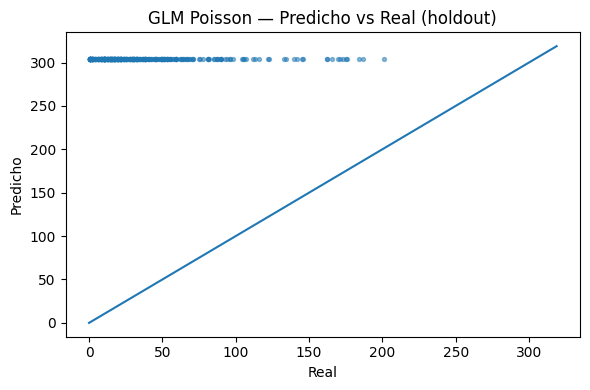

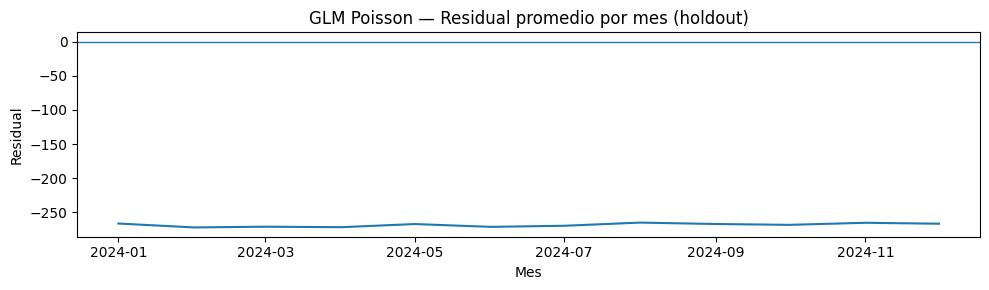


>>> Elastic Net (best CV)
CV (k=5) | MAE: 70.25 ± 35.35 | RMSE: 115.43 ± 70.04 | R²: -2.455 ± 5.829 | Poisson Dev: 266.44 ± 270.10
Holdout (12 meses) | MAE: 30.57 | RMSE: 39.60 | R²: -0.102 | Poisson Dev: 268.02


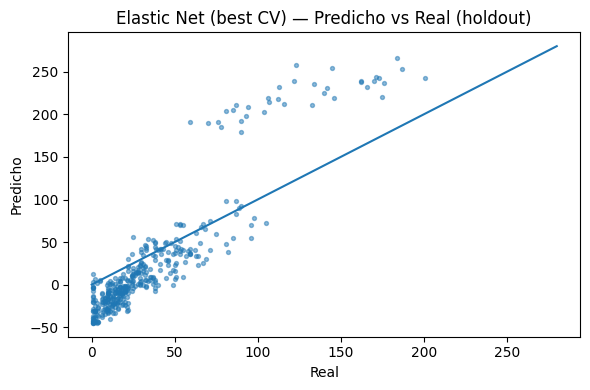

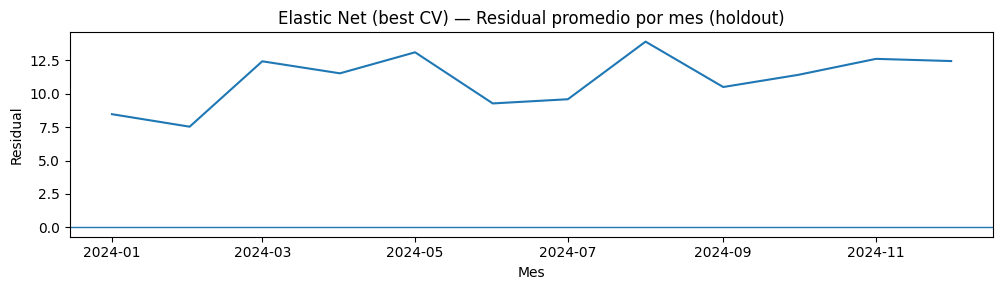


>>> HGB Poisson
CV (k=5) | MAE: 23.40 ± 11.93 | RMSE: 43.18 ± 22.34 | R²: 0.920 ± 0.107 | Poisson Dev: 6.34 ± 3.87
Holdout (12 meses) | MAE: 5.44 | RMSE: 9.13 | R²: 0.941 | Poisson Dev: 1.49


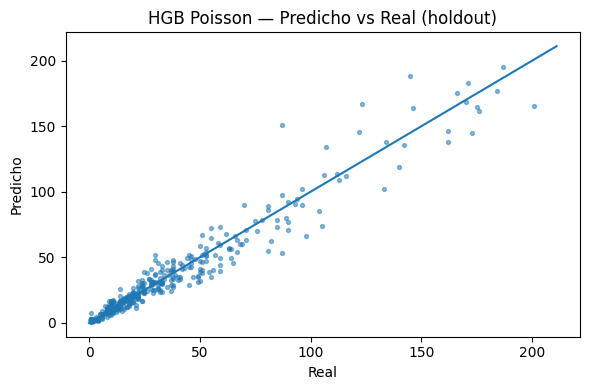

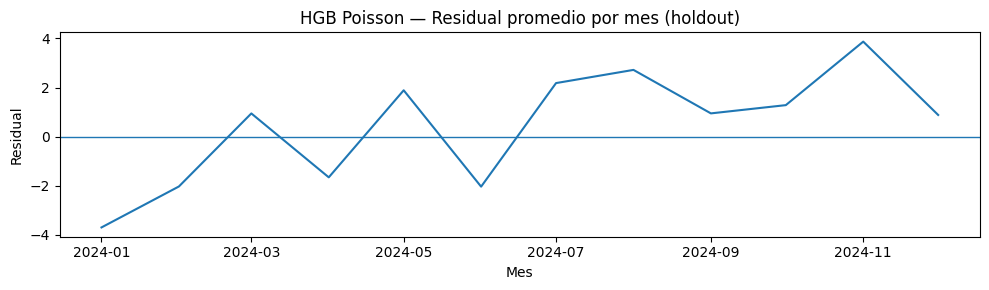


=== Comparativo de modelos (tabla) ===
     modelo     MAE_CV    RMSE_CV      R2_CV  PoissDev_CV     MAE_HO    RMSE_HO      R2_HO  PoissDev_HO
GLM Poisson 353.146564 462.340193 -27.898579   550.280814 268.526140 271.163144 -50.666224   417.837993
Elastic Net  70.252179 115.426305  -2.455188   266.443734  30.566902  39.597278  -0.101732   268.019824
HGB Poisson  23.398883  43.184866   0.920299     6.337725   5.435940   9.126821   0.941469     1.487114


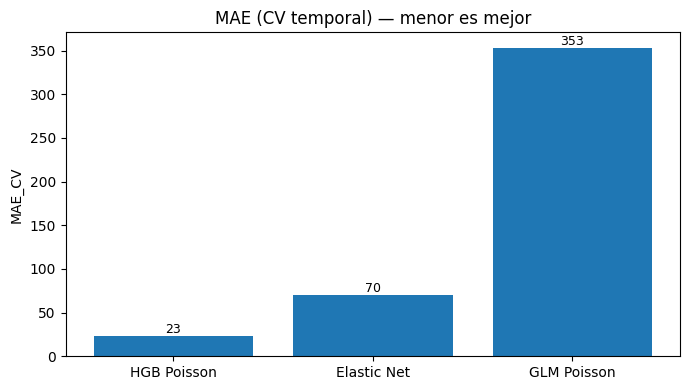

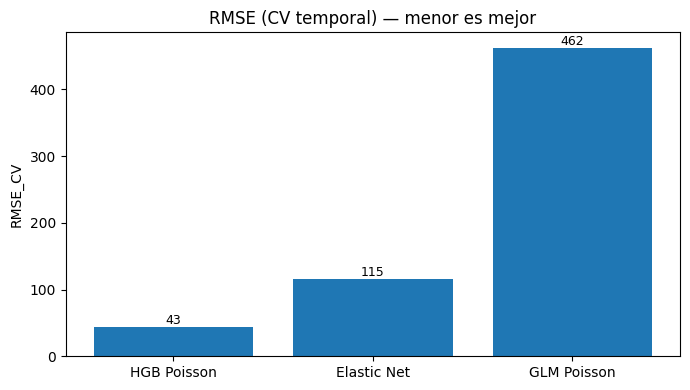

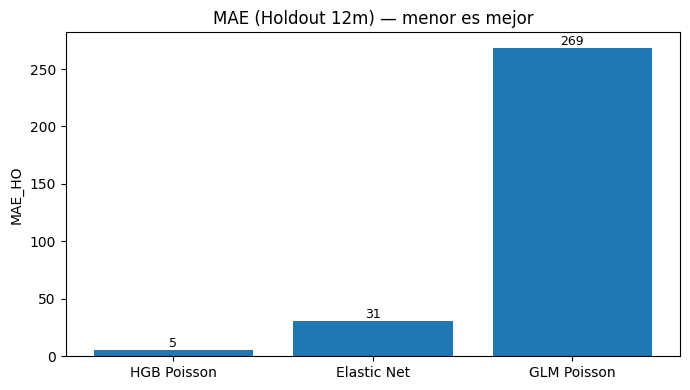

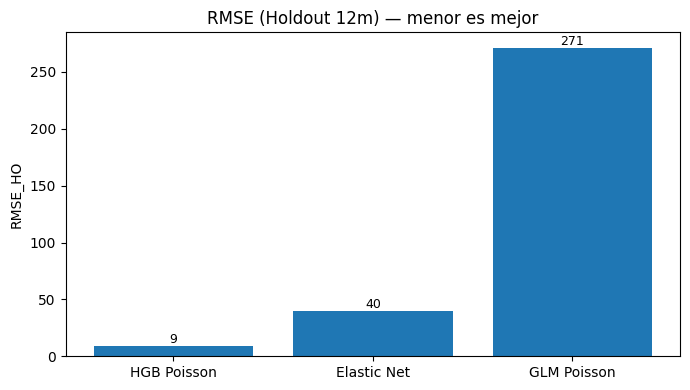

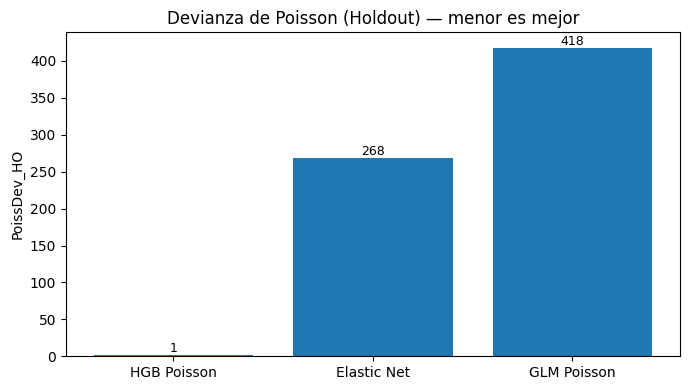

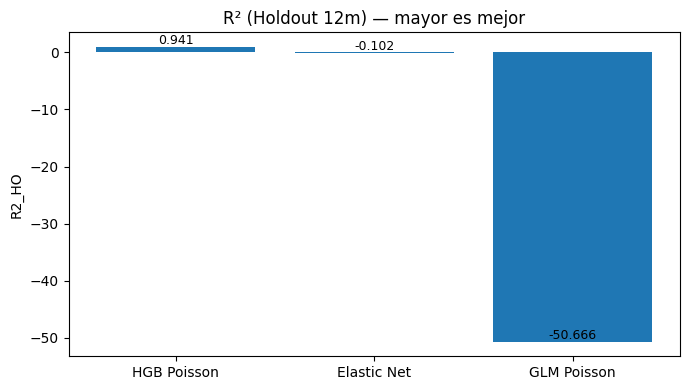

In [ ]:

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_poisson_deviance
from sklearn.linear_model import ElasticNet, PoissonRegressor
from sklearn.ensemble import HistGradientBoostingRegressor


PARQUET_IN = r"C:\Users\User\AppData\Local\Programs\Microsoft VS Code\outputs_fase2\df_limpio.parquet"
DEP_COL = "NOMBRE_DEPARTAMENTO_RESIDENCIA"
SCOPE_NATURALES = True        # True: solo NATURALES 
TOP_CAUSAS = 10               # Top causas homologadas para proporciones
TOP_EDADES = 10               # Top grupos etarios para proporciones
HOLDOUT_MESES = 12            # Últimos N meses para backtest
# ==========================================================

pd.set_option("display.width", 180)
pd.set_option("display.max_columns", 160)

# ---------- Utilidades de preparación ----------
def _build_fecha(df: pd.DataFrame) -> pd.DataFrame:
    if "FECHA" not in df.columns and {"ANO","MES"}.issubset(df.columns):
        anio = pd.to_numeric(df["ANO"], errors="coerce").astype("Int64")
        mes  = pd.to_numeric(df["MES"], errors="coerce").astype("Int64").fillna(1)
        df["FECHA"] = pd.to_datetime(
            dict(year=anio.fillna(2000).astype("int64"),
                 month=mes.astype("int64"),
                 day=1), errors="coerce"
        )
    return df

def _normalizar(df: pd.DataFrame) -> pd.DataFrame:
    if "PMAN_MUER_DESC" in df.columns:
        s = df["PMAN_MUER_DESC"].astype("string").fillna("No registra").str.strip()
        df["PMAN_MUER_DESC"] = s.replace("", "No registra")
    for c in ["CAU_HOMOL_DESC","GRU_ED1_DESC","SEXO_DESC","ASIS_MED_DESC"]:
        if c in df.columns:
            df[c] = df[c].astype("string").fillna("No registra").str.strip()
    return df

def _filtrar_naturales(df: pd.DataFrame) -> pd.DataFrame:
    if SCOPE_NATURALES and "PMAN_MUER_DESC" in df.columns:
        return df[df["PMAN_MUER_DESC"].str.upper() == "NATURAL"].copy()
    return df

def _armar_panel(df: pd.DataFrame) -> pd.DataFrame:
    grp = df.groupby([DEP_COL, "FECHA"], dropna=False)
    y = grp.size().rename("y_conteo")

    feats = []

    # Proporciones por sexo
    if "SEXO_DESC" in df.columns:
        sexo = (grp["SEXO_DESC"].value_counts(normalize=True)
                .rename("prop").reset_index()
                .pivot_table(index=[DEP_COL,"FECHA"], columns="SEXO_DESC", values="prop", fill_value=0))
        sexo.columns = [f"prop_sexo_{str(c).lower().replace(' ','_')}" for c in sexo.columns]
        feats.append(sexo)

    # Proporciones por grupo etario (Top-N global)
    if "GRU_ED1_DESC" in df.columns:
        top_ed = df["GRU_ED1_DESC"].value_counts().head(TOP_EDADES).index.tolist()
        ed = (grp["GRU_ED1_DESC"].value_counts(normalize=True)
              .rename("prop").reset_index())
        ed = ed[ed["GRU_ED1_DESC"].isin(top_ed)] \
             .pivot_table(index=[DEP_COL,"FECHA"], columns="GRU_ED1_DESC", values="prop", fill_value=0)
        ed.columns = [f"prop_edad_{re.sub(r'\\s+','_',c.lower())}" for c in ed.columns]
        feats.append(ed)

    # Proporciones por causa homologada (Top-N global)
    if "CAU_HOMOL_DESC" in df.columns:
        top_causas = df["CAU_HOMOL_DESC"].value_counts().head(TOP_CAUSAS).index.tolist()
        cz = (grp["CAU_HOMOL_DESC"].value_counts(normalize=True)
              .rename("prop").reset_index())
        cz = cz[cz["CAU_HOMOL_DESC"].isin(top_causas)] \
             .pivot_table(index=[DEP_COL,"FECHA"], columns="CAU_HOMOL_DESC", values="prop", fill_value=0)
        cz.columns = [f"prop_causa_{re.sub(r'\\s+','_',c.lower())}" for c in cz.columns]
        feats.append(cz)

    # Proporción de asistencia médica = "SÍ"
    if "ASIS_MED_DESC" in df.columns:
        am = grp["ASIS_MED_DESC"].apply(lambda s: (s.astype("string")=="SÍ").mean()) \
             .rename("prop_asistencia_si").to_frame()
        feats.append(am)

    # Consolidación
    X = y.to_frame()
    for f in feats:
        X = X.join(f, how="left")
    X = X.fillna(0).reset_index()

    # Lags por departamento (1 y 12 meses)
    X = X.sort_values(["FECHA", DEP_COL])
    for lag in [1, 12]:
        X[f"lag_{lag}"] = X.groupby(DEP_COL)["y_conteo"].shift(lag)
    X[["lag_1","lag_12"]] = X[["lag_1","lag_12"]].fillna(0)

    # Efectos fijos simples por departamento
    dummies_dep = pd.get_dummies(X[DEP_COL], prefix="dep", drop_first=True)
    X = pd.concat([X, dummies_dep], axis=1)

    return X

# ---------- Métricas y evaluación ----------
def _rmse(y_true, y_pred) -> float:
    return np.sqrt(mean_squared_error(y_true, y_pred))

def evaluar_modelo(nombre, modelo, X, y, t_index, holdout_meses=12):
    """
    Evaluación con CV temporal (k=5) y holdout final (N meses).
    Devuelve dict con métricas y muestra gráficos de holdout.
    """
    print(f"\n>>> {nombre}")

    no_features = [DEP_COL, "FECHA", "y_conteo"]
    feat_cols = [c for c in X.columns if c not in no_features]

    # Orden temporal
    order = np.argsort(t_index.values)
    Xo, yo, to = X.iloc[order], y.iloc[order], t_index.iloc[order]
    Xo[feat_cols] = Xo[feat_cols].replace([np.inf, -np.inf], np.nan).fillna(0)

    # CV temporal
    tscv = TimeSeriesSplit(n_splits=5)
    maes, rmses, r2s, pdevs = [], [], [], []
    for train_idx, test_idx in tscv.split(Xo):
        Xtr, Xte = Xo.iloc[train_idx][feat_cols], Xo.iloc[test_idx][feat_cols]
        ytr, yte = yo.iloc[train_idx], yo.iloc[test_idx]
        m = modelo
        m.fit(Xtr, ytr)
        pred = m.predict(Xte)
        maes.append(mean_absolute_error(yte, pred))
        rmses.append(_rmse(yte, pred))
        r2s.append(r2_score(yte, pred))
        pdevs.append(mean_poisson_deviance(yte, np.clip(pred, 1e-9, None)))

    print(f"CV (k=5) | MAE: {np.mean(maes):.2f} ± {np.std(maes):.2f}"
          f" | RMSE: {np.mean(rmses):.2f} ± {np.std(rmses):.2f}"
          f" | R²: {np.mean(r2s):.3f} ± {np.std(r2s):.3f}"
          f" | Poisson Dev: {np.mean(pdevs):.2f} ± {np.std(pdevs):.2f}")

    # Holdout (últimos N meses)
    meses_unicos = np.array(sorted(Xo["FECHA"].dt.to_period("M").unique()))
    if len(meses_unicos) <= 2:
        raise ValueError("Muy pocos meses únicos para hacer holdout.")
    corte = meses_unicos[-holdout_meses] if len(meses_unicos) > holdout_meses \
            else meses_unicos[int(len(meses_unicos)*0.8)]
    mask_hold = Xo["FECHA"].dt.to_period("M") >= corte

    Xtr, ytr = Xo.loc[~mask_hold, feat_cols], yo.loc[~mask_hold]
    Xho, yho = Xo.loc[mask_hold,  feat_cols], yo.loc[mask_hold]

    modelo.fit(Xtr, ytr)
    pred_ho = modelo.predict(Xho)

    mae_ho  = mean_absolute_error(yho, pred_ho)
    rmse_ho = _rmse(yho, pred_ho)
    r2_ho   = r2_score(yho, pred_ho)
    pdev_ho = mean_poisson_deviance(yho, np.clip(pred_ho, 1e-9, None))

    print(f"Holdout ({holdout_meses} meses) | MAE: {mae_ho:.2f} | RMSE: {rmse_ho:.2f} | R²: {r2_ho:.3f} | Poisson Dev: {pdev_ho:.2f}")

    # Gráfico Predicho vs Real
    plt.figure(figsize=(6,4))
    plt.scatter(yho, pred_ho, s=8, alpha=0.5)
    lim = [0, max(yho.max(), pred_ho.max())*1.05]
    plt.plot(lim, lim)
    plt.title(f"{nombre} — Predicho vs Real (holdout)")
    plt.xlabel("Real"); plt.ylabel("Predicho")
    plt.tight_layout(); plt.show()

    # Residuales promedio por mes (FIX aplicado)
    resid = yho - pred_ho
    df_res = pd.DataFrame({"FECHA": Xo.loc[mask_hold, "FECHA"].values,
                           "residual": resid})
    df_res = df_res.groupby(df_res["FECHA"].dt.to_period("M"))["residual"].mean()

    plt.figure(figsize=(10,3))
    plt.plot(df_res.index.to_timestamp(), df_res.values)
    plt.axhline(0, linewidth=1)
    plt.title(f"{nombre} — Residual promedio por mes (holdout)")
    plt.xlabel("Mes"); plt.ylabel("Residual")
    plt.tight_layout(); plt.show()

    return {
        "mae_cv": np.mean(maes), "rmse_cv": np.mean(rmses), "r2_cv": np.mean(r2s), "pdev_cv": np.mean(pdevs),
        "mae_ho": mae_ho, "rmse_ho": rmse_ho, "r2_ho": r2_ho, "pdev_ho": pdev_ho
    }

# ---------- Gráficos comparativos ----------
def _plot_barras_metricas(df, col_metric, titulo, invertir=False):
    d = df[["modelo", col_metric]].copy()
    d = d.sort_values(col_metric, ascending=invertir)  # menor=mejor -> ascendente
    plt.figure(figsize=(7, 4))
    plt.bar(d["modelo"], d[col_metric])
    for i, v in enumerate(d[col_metric].values):
        txt = f"{v:.0f}" if "R2" not in col_metric else f"{v:.3f}"
        plt.text(i, v, txt, ha="center", va="bottom", fontsize=9)
    plt.title(titulo)
    plt.ylabel(col_metric)
    plt.tight_layout()
    plt.show()

def reportar_y_graficar(res1, res2, res3):
    resumen = pd.DataFrame([
        ("GLM Poisson", res1["mae_cv"], res1["rmse_cv"], res1["r2_cv"], res1["pdev_cv"],
                         res1["mae_ho"], res1["rmse_ho"], res1["r2_ho"], res1["pdev_ho"]),
        ("Elastic Net", res2["mae_cv"], res2["rmse_cv"], res2["r2_cv"], res2["pdev_cv"],
                        res2["mae_ho"], res2["rmse_ho"], res2["r2_ho"], res2["pdev_ho"]),
        ("HGB Poisson", res3["mae_cv"], res3["rmse_cv"], res3["r2_cv"], res3["pdev_cv"],
                        res3["mae_ho"], res3["rmse_ho"], res3["r2_ho"], res3["pdev_ho"]),
    ], columns=["modelo","MAE_CV","RMSE_CV","R2_CV","PoissDev_CV","MAE_HO","RMSE_HO","R2_HO","PoissDev_HO"])

    print("\n=== Comparativo de modelos (tabla) ===")
    print(resumen.to_string(index=False))

    # CV
    _plot_barras_metricas(resumen, "MAE_CV",  "MAE (CV temporal) — menor es mejor", invertir=True)
    _plot_barras_metricas(resumen, "RMSE_CV", "RMSE (CV temporal) — menor es mejor", invertir=True)

    # Holdout
    _plot_barras_metricas(resumen, "MAE_HO",      "MAE (Holdout 12m) — menor es mejor", invertir=True)
    _plot_barras_metricas(resumen, "RMSE_HO",     "RMSE (Holdout 12m) — menor es mejor", invertir=True)
    _plot_barras_metricas(resumen, "PoissDev_HO", "Devianza de Poisson (Holdout) — menor es mejor", invertir=True)
    _plot_barras_metricas(resumen, "R2_HO",       "R² (Holdout 12m) — mayor es mejor", invertir=False)

    return resumen

# ---------- Main ----------
def main():
    # Carga y preparación
    df = pd.read_parquet(PARQUET_IN)
    df = _build_fecha(df)
    df = _normalizar(df)
    df = _filtrar_naturales(df)

    # Panel
    panel = _armar_panel(df)
    print(panel.head(3).to_string(index=False))
    print(f"\nPanel listo: {panel.shape[0]:,} filas × {panel.shape[1]} columnas")

    # Variables
    y = panel["y_conteo"]
    X = panel.copy()
    t_index = panel["FECHA"]

    # ===== Modelo 1: GLM Poisson =====
    mod1 = PoissonRegressor(alpha=1.0, max_iter=1000)
    res1 = evaluar_modelo("GLM Poisson", mod1, X, y, t_index, holdout_meses=HOLDOUT_MESES)

    # ===== Modelo 2: Elastic Net (con grid CV) =====
    pipe_en = Pipeline(steps=[
        ("scaler", StandardScaler(with_mean=False)),   # amigable con matrices dispersas
        ("en", ElasticNet(max_iter=5000))
    ])
    grid_en = {"en__alpha":[0.001, 0.01, 0.1, 1.0], "en__l1_ratio":[0.1, 0.5, 0.9]}
    tscv = TimeSeriesSplit(n_splits=5)
    gsen = GridSearchCV(pipe_en, grid_en, cv=tscv, scoring="neg_mean_absolute_error", n_jobs=-1)
    no_features = [DEP_COL, "FECHA", "y_conteo"]
    feat_cols = [c for c in X.columns if c not in no_features]
    gsen.fit(X[feat_cols], y)
    best_en = gsen.best_estimator_
    res2 = evaluar_modelo("Elastic Net (best CV)", best_en, X, y, t_index, holdout_meses=HOLDOUT_MESES)

    # ===== Modelo 3: HGB Poisson =====
    hgb = HistGradientBoostingRegressor(loss="poisson",
                                        learning_rate=0.08,
                                        max_depth=6,
                                        max_iter=400,
                                        l2_regularization=0.0)
    res3 = evaluar_modelo("HGB Poisson", hgb, X, y, t_index, holdout_meses=HOLDOUT_MESES)

    # ===== Comparativo de métricas (tabla + gráficos) =====
    reportar_y_graficar(res1, res2, res3)

if __name__ == "__main__":
    main()

